In [259]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yanishelali/dataset1/WA_Fn-UseC_-Telco-Customer-Churn.csv


# Jour 3 — Phase 0 : Setup des algorithmes

Objectif :
- repartir du dataset nettoyé
- préparer les données pour les algorithmes de Machine Learning
- vérifier que le pipeline fonctionne

Nous utilisons le dataset Telco Customer Churn nettoyé au Jour 2.

In [260]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/yanishelali/dataset1/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape :", df.shape)
df.head()

Shape : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [261]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [262]:
df = df.drop(columns=["customerID"])

In [263]:
binary_map = {"Yes": 1, "No": 0}

binary_cols = df.columns[df.nunique() == 2]

for col in binary_cols:
    df[col] = df[col].map(binary_map)

df = pd.get_dummies(df, drop_first=True)

In [264]:
df = df.drop(columns=["TotalCharges"])

In [265]:
print("Shape :", df.shape)
print(df.dtypes)

Shape : (7043, 30)
gender                                   float64
SeniorCitizen                            float64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
T

## Conclusion Phase 0

Le dataset est maintenant :

- nettoyé
- encodé
- sans variables redondantes
- prêt à être utilisé avec des algorithmes

On peut maintenant tester différents modèles de Machine Learning.

# Jour 3 — Phase A : L'Arène des algorithmes

Objectif :
Comparer plusieurs modèles de Machine Learning sur le dataset Telco Customer Churn.

Modèles testés :
- Régression logistique
- Arbre de décision
- Random Forest
- KNN

Critère d’évaluation :
- Accuracy

But :
Identifier le modèle le plus performant.


In [266]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [267]:
import pandas as pd

# Chargement
df = pd.read_csv("/kaggle/input/datasets/yanishelali/dataset1/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Supprimer ID
df = df.drop(columns=["customerID"])

In [268]:
# Colonnes catégorielles
categorical_cols = df.select_dtypes(include=["object"]).columns

# Mapping binary Yes/No UNIQUEMENT
for col in categorical_cols:
    if set(df[col].unique()) == {"Yes", "No"}:
        df[col] = df[col].map({"Yes": 1, "No": 0})

# One-hot pour le reste
df = pd.get_dummies(df, drop_first=True)

In [269]:
# Variable redondante
df = df.drop(columns=["TotalCharges"])

In [270]:
print("NaN restants :", df.isna().sum().sum())
print("Shape :", df.shape)

NaN restants : 0
Shape : (7043, 30)


In [271]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [272]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [273]:
## Fonction d'entraînement et d'évaluation

In [274]:
def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [275]:
## Comparaison des modèles

In [276]:
modeles = {
    "Régression Logistique": LogisticRegression(max_iter=1000),
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

resultats = []

for nom, modele in modeles.items():
    score = entrainer_et_evaluer(
        modele,
        X_train,
        X_test,
        y_train,
        y_test
    )
    resultats.append((nom, score))

In [277]:
resultats = sorted(resultats, key=lambda x: x[1], reverse=True)

print("=== Classement des modèles ===\n")

for i, (nom, score) in enumerate(resultats, start=1):
    print(f"{i}. {nom} : {score:.2%}")

=== Classement des modèles ===

1. Régression Logistique : 79.84%
2. Random Forest : 79.06%
3. KNN (k=5) : 76.37%
4. Arbre de décision : 71.89%


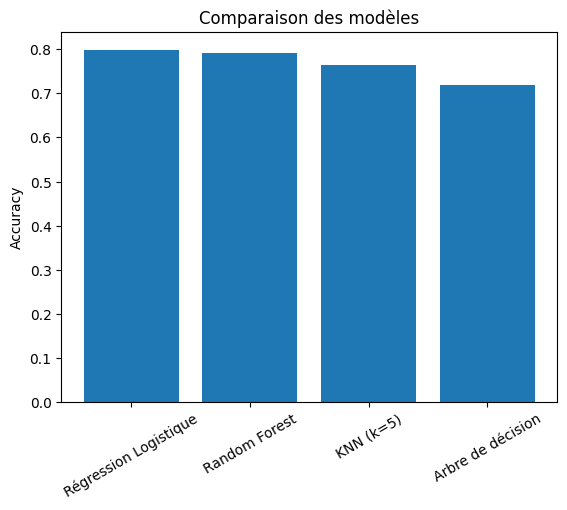

In [278]:
import matplotlib.pyplot as plt

noms = [nom for nom, score in resultats]
scores = [score for nom, score in resultats]

plt.figure()
plt.bar(noms, scores)

plt.title("Comparaison des modèles")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

# Phase B — Optimisation des modèles

Objectif :
Améliorer les performances des modèles en ajustant leurs hyperparamètres.

Méthodes :
- test manuel de paramètres
- comparaison des résultats

But :
obtenir un meilleur score que la Phase A.

In [279]:
def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [280]:
## Optimisation du KNN

In [281]:
knn_resultats = []

for k in [3, 5, 7, 10, 15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    score = entrainer_et_evaluer(
        knn,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    knn_resultats.append((k, score))

In [282]:
print("=== KNN tuning ===")

for k, score in knn_resultats:
    print(f"k = {k} → {score:.2%}")

=== KNN tuning ===
k = 3 → 75.37%
k = 5 → 76.37%
k = 7 → 77.29%
k = 10 → 78.21%
k = 15 → 78.00%


## Optimisation de l'Arbre de décision

In [283]:
tree_resultats = []

for depth in [3, 5, 10, 15, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    score = entrainer_et_evaluer(
        tree,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    tree_resultats.append((depth, score))


In [284]:
print("=== Decision Tree tuning ===")

for depth, score in tree_resultats:
    print(f"max_depth = {depth} → {score:.2%}")

=== Decision Tree tuning ===
max_depth = 3 → 78.71%
max_depth = 5 → 79.35%
max_depth = 10 → 76.15%
max_depth = 15 → 72.89%
max_depth = None → 71.89%


## Optimisation du Random Forest

In [285]:
rf_resultats = []

for n in [50, 100, 200]:
    for depth in [5, 10, None]:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )
        
        score = entrainer_et_evaluer(
            rf,
            X_train,
            X_test,
            y_train,
            y_test
        )
        
        rf_resultats.append((n, depth, score))

In [286]:
print("=== Random Forest tuning ===")

for n, depth, score in rf_resultats:
    print(f"n_estimators={n}, max_depth={depth} → {score:.2%}")

=== Random Forest tuning ===
n_estimators=50, max_depth=5 → 78.57%
n_estimators=50, max_depth=10 → 80.20%
n_estimators=50, max_depth=None → 78.35%
n_estimators=100, max_depth=5 → 78.85%
n_estimators=100, max_depth=10 → 80.20%
n_estimators=100, max_depth=None → 79.06%
n_estimators=200, max_depth=5 → 78.78%
n_estimators=200, max_depth=10 → 79.91%
n_estimators=200, max_depth=None → 78.50%


In [287]:
best_knn = max(knn_resultats, key=lambda x: x[1])
best_tree = max(tree_resultats, key=lambda x: x[1])
best_rf = max(rf_resultats, key=lambda x: x[2])

print("=== Meilleurs modèles ===")
print(f"KNN : k={best_knn[0]} → {best_knn[1]:.2%}")
print(f"Tree : depth={best_tree[0]} → {best_tree[1]:.2%}")
print(f"RF : n={best_rf[0]}, depth={best_rf[1]} → {best_rf[2]:.2%}")

=== Meilleurs modèles ===
KNN : k=10 → 78.21%
Tree : depth=5 → 79.35%
RF : n=50, depth=10 → 80.20%


In [288]:
final_models = [
    ("KNN optimisé", best_knn[1]),
    ("Tree optimisé", best_tree[1]),
    ("Random Forest optimisé", best_rf[2])
]

final_models = sorted(final_models, key=lambda x: x[1], reverse=True)

print("\n=== Classement final ===")

for nom, score in final_models:
    print(f"{nom} : {score:.2%}")


=== Classement final ===
Random Forest optimisé : 80.20%
Tree optimisé : 79.35%
KNN optimisé : 78.21%


## Analyse

L’optimisation des hyperparamètres permet d’améliorer les performances des modèles.

Observations :

- le choix du bon k améliore le KNN
- limiter la profondeur évite l’overfitting pour l’arbre
- Random Forest reste le modèle le plus performant

Conclusion :

Le tuning améliore les performances globales.
Le Random Forest optimisé reste le meilleur modèle.

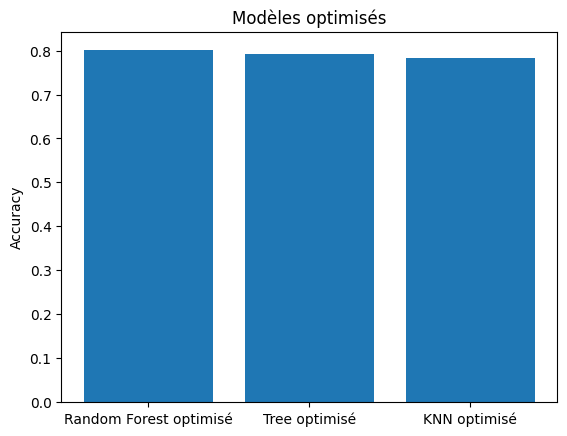

In [289]:
import matplotlib.pyplot as plt

noms = [nom for nom, score in final_models]
scores = [score for nom, score in final_models]

plt.figure()
plt.bar(noms, scores)

plt.title("Modèles optimisés")
plt.ylabel("Accuracy")
plt.show()

# Phase C — Pipeline et Data Leakage

Objectif :
Construire un pipeline Machine Learning propre et éviter toute fuite de données.

Concept clé :
- toutes les transformations doivent être apprises uniquement sur le train

Solution :
- utiliser Pipeline de scikit-learn

In [290]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [291]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [292]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Pipeline Machine Learning

In [293]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=300))
])

In [294]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=300))])

In [295]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy (pipeline propre) : {accuracy:.2%}")

Accuracy (pipeline propre) : 79.77%


## Démonstration du Data Leakage

In [296]:
# ❌ FAUX : scaler appliqué avant le split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=300)
model.fit(X_train_bad, y_train_bad)

y_pred_bad = model.predict(X_test_bad)

accuracy_bad = accuracy_score(y_test_bad, y_pred_bad)

print(f"Accuracy FAUSSE (data leakage) : {accuracy_bad:.2%}")

Accuracy FAUSSE (data leakage) : 79.70%


## Analyse du Data Leakage

Observation :

- la performance avec data leakage peut être artificiellement élevée

Problème :

- le modèle a indirectement appris des données de test

Conclusion :

Toujours :
- faire le split AVANT toute transformation
- utiliser Pipeline pour éviter les erreurs

Le pipeline garantit un workflow correct.

# Phase D — Évaluation avancée des modèles

Objectif :
Analyser plus finement les performances des modèles.

Metrics utilisées :
- matrice de confusion
- précision
- recall
- F1-score

But :
mieux comprendre les erreurs du modèle.

In [297]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [298]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)


## Matrice de confusion

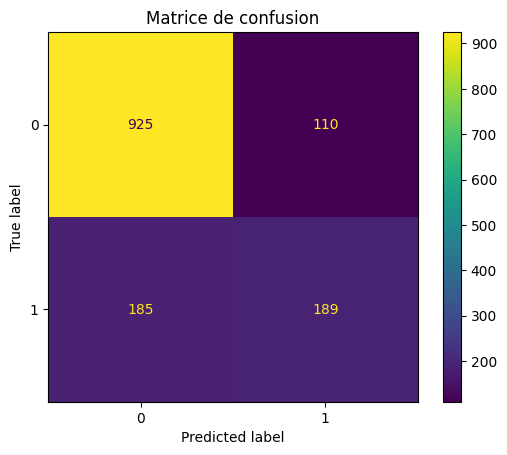

In [299]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion")
plt.show()

## Classification Report

In [300]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## Analyse

La matrice de confusion permet d’observer :

- les bonnes prédictions (diagonale)
- les erreurs (hors diagonale)

Observations :

- le modèle prédit correctement la majorité des "No"
- les "Yes" (churn) sont plus difficiles à détecter
- il existe des faux négatifs (clients qui churnent non détectés)

Interprétation métier :

- un faux négatif = client qui part sans être détecté (grave)
- un faux positif = client qu’on pense à risque mais qui ne part pas (coût marketing)

Conclusion :

Le recall est une métrique clé pour ce problème.
Il est préférable de détecter un maximum de churns.

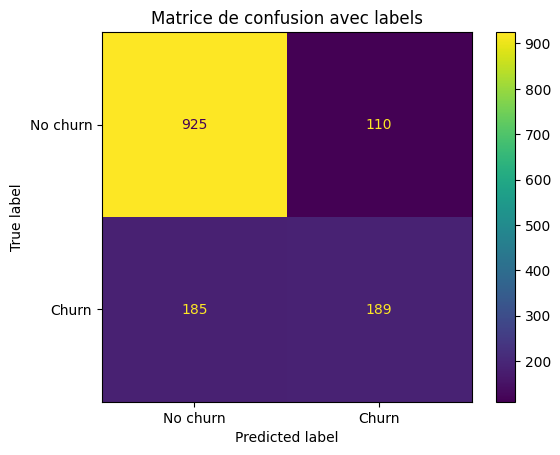

In [301]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No churn", "Churn"]
)

disp.plot()
plt.title("Matrice de confusion avec labels")
plt.show()
